1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
Layer: block5_conv1, Feature map shape: (1, 2, 2, 512)


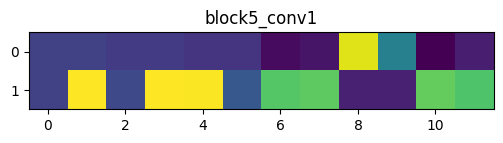

Layer: block5_conv2, Feature map shape: (1, 2, 2, 512)


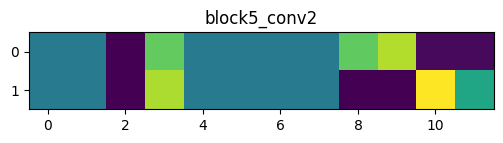

Layer: block5_conv3, Feature map shape: (1, 2, 2, 512)


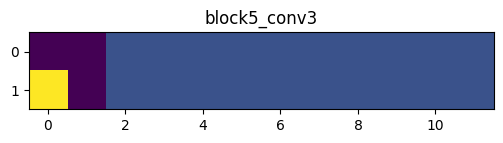

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import requests
from PIL import Image
from io import BytesIO
from tensorflow.keras.datasets import cifar10

# --- Load base model as in your code ---
size = 32
vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(size, size, 3))
vgg16_base_model.trainable = False

# --- Load CIFAR-10 dataset and select a sample image ---
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
img = x_test[0] # Select the first image from the test set

# Convert numpy array to PIL Image to use image preprocessing functions
img = Image.fromarray(img)

img = img.resize((size, size))
img = image.img_to_array(img)

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)


# --- Create a new model to extract intermediate feature maps from selected layers ---
layer_names_to_visualize = []
# Select a few convolutional layers to visualize (adjust as needed)
for layer in reversed(vgg16_base_model.layers):
    if 'conv' in layer.name:
        layer_names_to_visualize.append(layer.name)
    if len(layer_names_to_visualize) == 3: # Select 3 layers
        break

# Reverse to visualize from earlier to later layers
layer_names_to_visualize.reverse()

layer_outputs = [vgg16_base_model.get_layer(name).output for name in layer_names_to_visualize]
activation_model = Model(inputs=vgg16_base_model.input, outputs=layer_outputs)


# --- Get feature maps ---
activations = activation_model.predict(x)

# --- Visualize the feature maps from the selected layers ---
for layer_name, feature_map in zip(layer_names_to_visualize, activations):
    print(f"Layer: {layer_name}, Feature map shape: {feature_map.shape}")

    # Plot first 6 feature maps for each layer
    n_features = feature_map.shape[-1]
    size = feature_map.shape[1]

    display_grid = np.zeros((size, size * min(6, n_features)))
    for i in range(min(6, n_features)): # Ensure we don't try to plot more features than exist
        channel_image = feature_map[0, :, :, i]
        channel_image -= channel_image.mean()
        channel_image /= (channel_image.std() + 1e-5)
        channel_image *= 64
        channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()